# 01 — Exploratory Data Analysis

Explores the three raw datasets (Naukri jobs, LinkedIn jobs, Resume dataset) before any cleaning,
and then inspects the unified job corpus produced by `src/data/preprocess.py`.

Run this after placing your raw CSVs in `data/raw/` (see README for exact filenames).

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data, preprocess
from src import config

pd.set_option('display.max_colwidth', 120)

## 1. Load raw datasets

In [2]:
naukri = load_data.load_naukri()
linkedin = load_data.load_linkedin()
resumes = load_data.load_resumes()

print('Naukri:', naukri.shape)
print('LinkedIn:', linkedin.shape)
print('Resumes:', resumes.shape)

Naukri: (36643, 7)
LinkedIn: (24376, 3)
Resumes: (2679, 2)


In [3]:
naukri.head(3)

,title,company,experience,salary,location,job-description,skills
0,Customer Engineer,NCR Corporation,2-7 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru",Provides prompt and courteous service responses to routine customer enquiries (for Tier...,a+ technology recruitment customer engineering inventory service level customer satisfaction n+
1,Service Operation Manager,Rackspace Technology,4-8 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru","Managing a busy change team mailbox and ticketing queue, prioritising and actioning ite...",rackspace change management service operations technology management incident management analysis ticketing rca
2,Service Operation Manager,Rackspace Technology,4-9 Yrs,Not disclosed,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru","Managing a busy change team mailbox and ticketing queue, prioritising and actioning ite...",operations management change management delivery rackspace service operations technology management analysis ticketing


In [4]:
linkedin.head(3)

,title,description,skills
0,Data Science Director,Altoida is a pioneer in developing digital biomarkers of neurological disease using augmented reality and machine le...,['Generative ML methods' 'Discriminative ML methods'\n 'Contrastive ML methods' 'Classification techniques'\n 'Gradi...
1,Senior Data Scientist,"Veeva Systems is a mission-driven organization and pioneer in industry cloud, helping life sciences companies bring ...",['Natural Language Processing (NLP)' 'Machine Learning' 'Deep Learning'\n 'Large Language Models (LLMs)'\n 'Transfor...
2,Staff Data Scientist,"To get the best candidate experience, please consider applying for a maximum of 3 roles within 12 months to ensure y...","['SQL' 'Programming language for data analysis (e.g., Python, R)'\n 'Statistical methods' 'Machine learning methods']"


In [5]:
resumes.head(3)

,Category,Resume
0,HR,"TECHNICAL SKILLS â¢ Typewriting â¢ TORA â¢ SPSSEducation Details \r\nJanuary 2017 MBA Chidambaram, Tamil Nadu SN..."
1,HR,"I.T. Skills â¢ Windows XP, Ms Office (Word, Excel: Look-ups; Pivot table; other basic functions ; Power Point) â¢ ..."
2,HR,Education Details \r\n BA mumbai University\r\nHR \r\n\r\n\r\nSkill Details \r\nHr Operations- Exprience - Less th...


## 2. Resume category balance
How many resumes per category? This matters for classifier evaluation (macro F1, class_weight='balanced').

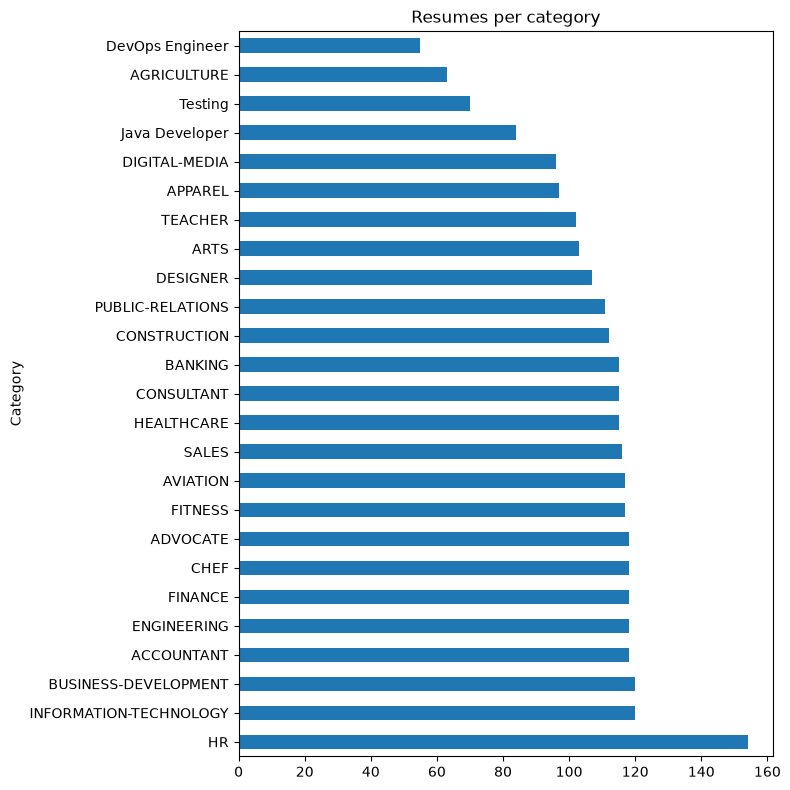

In [6]:
resumes['Category'].value_counts().plot(kind='barh', figsize=(8,8))
plt.title('Resumes per category')
plt.tight_layout()
plt.show()

## 3. Resume length distribution

In [7]:
resumes['Resume'].str.len().describe()

count     2679.000000
mean      5885.084733
std       2941.709395
min         21.000000
25%       4850.000000
50%       5704.000000
75%       7005.000000
max      38842.000000
Name: Resume, dtype: float64

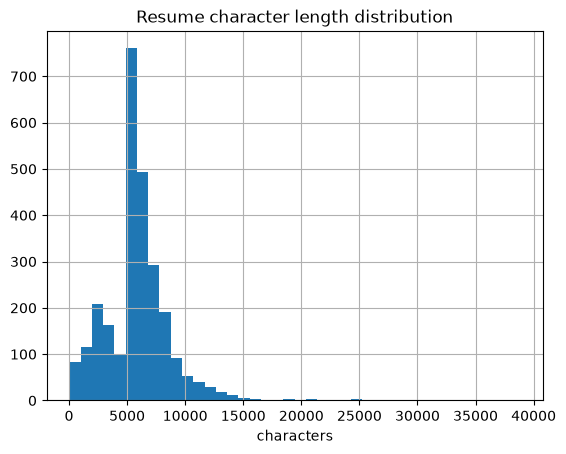

In [8]:
resumes['Resume'].str.len().hist(bins=40)
plt.title('Resume character length distribution')
plt.xlabel('characters')
plt.show()

## 4. Build the unified job corpus
This calls the same `build_job_corpus` function used by `scripts/train_all.py`, so the notebook and the production pipeline never drift apart.

In [9]:
job_corpus = preprocess.build_job_corpus(naukri, linkedin)
print(job_corpus.shape)
job_corpus.head(3)

(58089, 16)


,title,company,location,skills_text,skills_list,description,experience,exp_min,exp_max,salary,source,clean_title,clean_description,clean_skills,search_text,job_id
0,Customer Engineer,NCR Corporation,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru",a+ technology recruitment customer engineering inventory service level satisfaction n+,"[a+, technology, recruitment, customer, engineering, inventory, service, level, satisfaction, n+]",Provides prompt and courteous service responses to routine customer enquiries (for Tier...,2-7 Yrs,2.0,7.0,Not disclosed,naukri,customer engineer,provides prompt and courteous service responses to routine customer enquiries for tier...,a+ technology recruitment customer engineering inventory service level satisfaction n+,customer engineer customer engineer customer engineer a+ technology recruitment customer engineering inventory servi...,0
1,Service Operation Manager,Rackspace Technology,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru",rackspace change management service operations technology incident analysis ticketing rca,"[rackspace, change, management, service, operations, technology, incident, analysis, ticketing, rca]","Managing a busy change team mailbox and ticketing queue, prioritising and actioning ite...",4-8 Yrs,4.0,8.0,Not disclosed,naukri,service operation manager,managing a busy change team mailbox and ticketing queue prioritising and actioning ite...,rackspace change management service operations technology incident analysis ticketing rca,service operation manager service operation manager service operation manager rackspace change management service op...,1
2,"Senior Manager, Business Operations",Rackspace Technology,"Kolkata, Mumbai, New Delhi, Hyderabad/Secunderabad, Pune, Chennai, Bangalore/Bengaluru",management senior mis automation analysis project intelligence business operations,"[management, senior, mis, automation, analysis, project, intelligence, business, operations]",Required bachelor s degree in data analytics or technology related field . 8 - 10 years...,3-15 Yrs,3.0,15.0,Not disclosed,naukri,senior manager business operations,required bachelor s degree in data analytics or technology related field . 8 - 10 years...,management senior mis automation analysis project intelligence business operations,senior manager business operations senior manager business operations senior manager business operations management ...,2


## 5. Job corpus sanity checks

In [10]:
job_corpus['source'].value_counts()

source
naukri      33714
linkedin    24375
Name: count, dtype: int64

In [11]:
job_corpus['search_text'].str.len().describe()

count    58089.000000
mean      2110.875346
std       2011.745455
min         74.000000
25%        376.000000
50%       1534.000000
75%       3066.000000
max      22192.000000
Name: search_text, dtype: float64

In [12]:
top_titles = job_corpus['clean_title'].value_counts().head(20)
top_titles

clean_title
data scientist                    492
senior data scientist             342
business analyst                  266
senior software engineer          162
software engineer                 142
customer support executive        139
data analyst                      130
java developer                    125
business development manager      118
project manager                   115
customer care executive           109
business development executive    103
registered nurse - rn - ltac      100
data engineer                      93
android developer                  85
network engineer                   81
php developer                      78
web designer                       72
sales manager                      72
sales executive                    71
Name: count, dtype: int64

## 6. Experience range distribution (Naukri only)

In [13]:
naukri_jobs = job_corpus[job_corpus['source'] == 'naukri']
naukri_jobs[['exp_min','exp_max']].describe()

,exp_min,exp_max
count,33714.000000,33714.000000
mean,1.849736,3.643175
std,2.744495,4.301393
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,2.000000
75%,3.000000,6.000000
max,25.000000,30.000000


## Takeaways
- The job corpus merges Naukri + LinkedIn into one consistent schema (`title`, `company`, `location`, `skills_text`, `description`, `experience`).
- Resume categories are imbalanced — the classifier notebook (02) uses `class_weight='balanced'` to compensate.
- `search_text` (title×3 + skills×2 + description) is what gets vectorized for the recommender — see notebook 03.